In [18]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

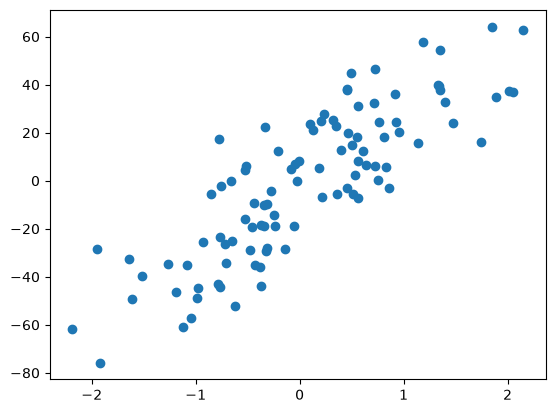

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)



In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [40]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [21]:
np.mean(cross_val_score(lr,X,y,cv=10,scoring='r2'))

np.float64(0.6375011587464419)

In [6]:
m=29.19

In [27]:
# class GDregressor:
#     def __init__(self, lr=0.01, n_iters=1000):
#         self.lr = lr
#         self.n_iters = n_iters
#         self.m = 29.19
#         self.b = -120

#     def fit(self, X, y):
#         # calculate the b using GD
#         for i in range(self.n_iters):
#             loss_slope = -2 * np.sum(y - self.m*X.ravel() - self.b)
#             self.b = self.b - self.lr * loss_slope
#             # print("Iteration ", i, "b = ", self.b)
#         print("b = ", self.b)

class GDregressor:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.m = 29.19
        self.b = -120

    def fit(self, X, y):
        # calculate the b using GD
        for i in range(self.n_iters):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())
            self.b = self.b - self.lr * loss_slope_b
            self.m = self.m - self.lr * loss_slope_m
            # print("Iteration ", i, "b = ", self.b)
        print("b = ", self.b, "m = ", self.m)

    def predict(self, X):
        return self.m * X.ravel() + self.b

In [ ]:
# for high learning rate, the b is not converging to the optimal value. It is oscillating around the optimal value. For low learning rate, the b is converging to the optimal value but it is taking more time to converge.
gd_reg = GDregressor(lr=0.01, n_iters=1000) 
gd_reg.fit(X, y)

Iteration  0 b =  115.251419783106
Iteration  1 b =  -120.00000000000003
Iteration  2 b =  115.25141978310597
Iteration  3 b =  -120.00000000000003
Iteration  4 b =  115.25141978310597
Iteration  5 b =  -120.00000000000003
Iteration  6 b =  115.25141978310597
Iteration  7 b =  -120.00000000000003
Iteration  8 b =  115.25141978310597
Iteration  9 b =  -120.00000000000003
Iteration  10 b =  115.25141978310597
Iteration  11 b =  -120.00000000000003
Iteration  12 b =  115.25141978310597
Iteration  13 b =  -120.00000000000003
Iteration  14 b =  115.25141978310597
Iteration  15 b =  -120.00000000000003
Iteration  16 b =  115.25141978310597
Iteration  17 b =  -120.00000000000003
Iteration  18 b =  115.25141978310597
Iteration  19 b =  -120.00000000000003
Iteration  20 b =  115.25141978310597
Iteration  21 b =  -120.00000000000003
Iteration  22 b =  115.25141978310597
Iteration  23 b =  -120.00000000000003
Iteration  24 b =  115.25141978310597
Iteration  25 b =  -120.00000000000003
Iteration  

In [23]:
gd_reg = GDregressor(lr=0.001, n_iters=1000)
gd_reg.fit(X, y)

b =  -2.2947445586769812 m =  27.828091032520142


In [37]:
gd_reg = GDregressor(lr=0.0001, n_iters=1000)
gd_reg.fit(X_train, y_train)

b =  -2.271031854356286 m =  28.125990340180227


In [38]:
gd_reg.predict(X_test)

array([ 21.09901265,  18.03495038,  18.23746913,  -8.10294747,
        15.7263386 ,  58.21061871, -15.03326695, -11.33107872,
       -15.81007965,  -8.80823969, -23.57515396,  14.78143705,
        12.70149845, -23.88942802, -22.30772473, -16.67055715,
        24.52827271, -16.98554351,  -3.88918724, -12.01969101])

In [39]:
r2 = r2_score(y_test, gd_reg.predict(X_test))

In [34]:
r2

0.635782745363241